# Libraries

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random


# 01 — The Coin Experiment

## Question
**What happens when we repeatedly flip a fair coin?**

## Theoretical probabilities



$$P(Heads) = 0.5$$

$$P(Tails) = 0.5$$

## One coin flip

$$P(H)=P(T)=\frac{1}{2}=0.5$$

In [101]:
# Run this cell as much as you want
outcome = np.random.choice(["H", "T"])
print("Coin flip result:", outcome)

Coin flip result: H


## N coin flips

In [121]:
# Flipping a coin 10 times
## Run this cell as much as you want
flips = np.random.choice(["H", "T"], size=10)

print("Results:", flips)

heads_count = np.sum(flips == "H")
tails_count = np.sum(flips == "T")

print("Heads:", heads_count)
print("Tails:", tails_count)

heads_frequency = heads_count / len(flips)

print(f"Observed Heads frequency: {heads_frequency} ({heads_frequency*100}%)")

Results: ['H' 'H' 'H' 'T' 'H' 'T' 'T' 'T' 'T' 'T']
Heads: 4
Tails: 6
Observed Heads frequency: 0.4 (40.0%)


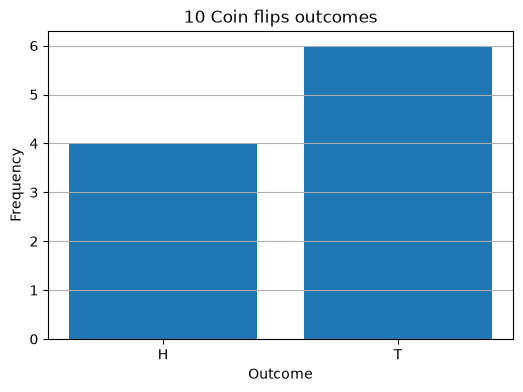

In [126]:
# Visualizing

plt.figure(figsize=(6,4))

plt.bar(('H', 'T'), height=(heads_count, tails_count))
plt.title("10 Coin flips outcomes")
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.grid(axis='y')

plt.show()

For example, if we get 6 "H"...

$$f(H)=\frac{6}{10}=0.6=60\%$$

In [128]:
# 1000 coin flips

flips_1000 = np.random.choice(
    ["H", "T"],
    size=1000
)

heads_count_1000 = np.sum(flips_1000 == "H")
tails_count_1000 = np.sum(flips_1000 == "T")
heads_frequency_1000 = heads_count_1000 / len(flips_1000)

print("Total flips:", len(flips_1000))
print("Heads:", heads_count_1000)
print("Tails:", tails_count_1000)
print("Observed Heads frequency:", heads_frequency_1000)
print("Observed Heads percentage:", heads_frequency_1000 * 100, "%")
print("Theoretical Heads probability:", 50, "%")

Total flips: 1000
Heads: 510
Tails: 490
Observed Heads frequency: 0.51
Observed Heads percentage: 51.0 %
Theoretical Heads probability: 50 %


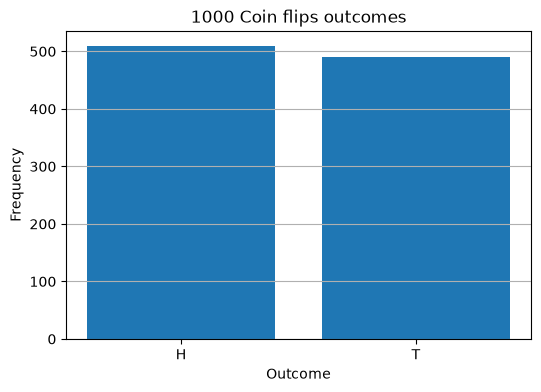

In [129]:
# Visualizing

plt.figure(figsize=(6,4))

plt.bar(('H', 'T'), height=(heads_count_1000, tails_count_1000))
plt.title("1000 Coin flips outcomes")
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.grid(axis='y')

plt.show()

## How Law of Large Numbers behave? 

In [144]:
# After 1000 flips
flips = np.random.choice(
    ["Heads", "Tails"],
    size=1000
)

is_heads = (flips == "Heads")

# cumsum the "heads"
cumulative_heads = np.cumsum(is_heads)
# making an array of total frequencies (flips)
number_of_flips = np.arange(1, len(flips) + 1)

cumulative_frequency = cumulative_heads / number_of_flips

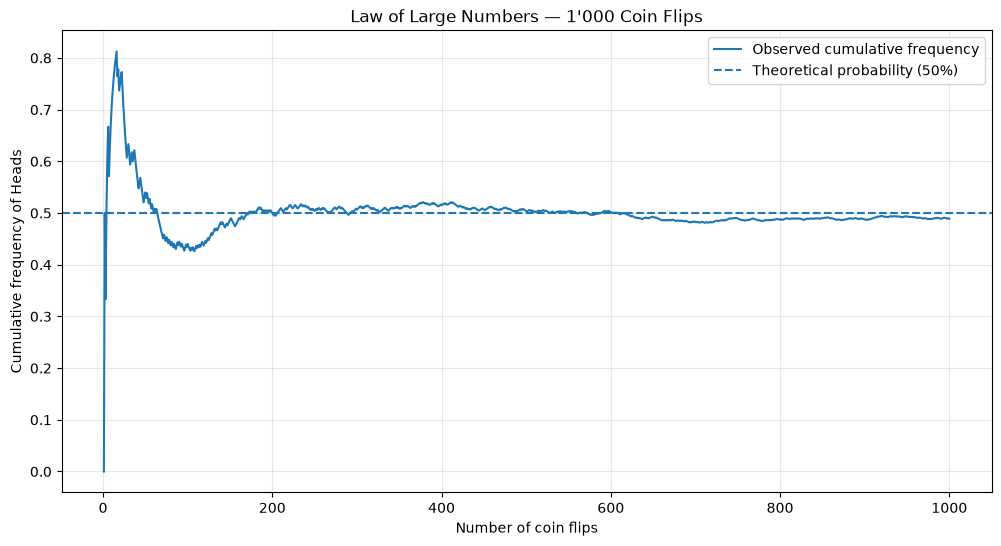

In [145]:
# Visualizing

plt.figure(figsize=(12, 6))

plt.plot(number_of_flips, cumulative_frequency,
         label="Observed cumulative frequency")

plt.axhline(y=0.5, linestyle="--",
            label="Theoretical probability (50%)")

plt.xlabel("Number of coin flips")
plt.ylabel("Cumulative frequency of Heads")
plt.title("Law of Large Numbers — 1'000 Coin Flips")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Simulating N experiments of X coin flips

In [146]:
# parameters
n_experiments = 20
x_flips = 1000

# seed
rng = np.random.default_rng(seed=42)

# generating independent flips
flips = rng.choice(
    [0, 1],
    size=(n_experiments, x_flips)
)

# calculating cumulative Heads (1) frequency for every scenario
cumulative_heads = np.cumsum(flips, axis=1)
flip_numbers = np.arange(1, x_flips + 1)
cumulative_frequency = cumulative_heads / flip_numbers

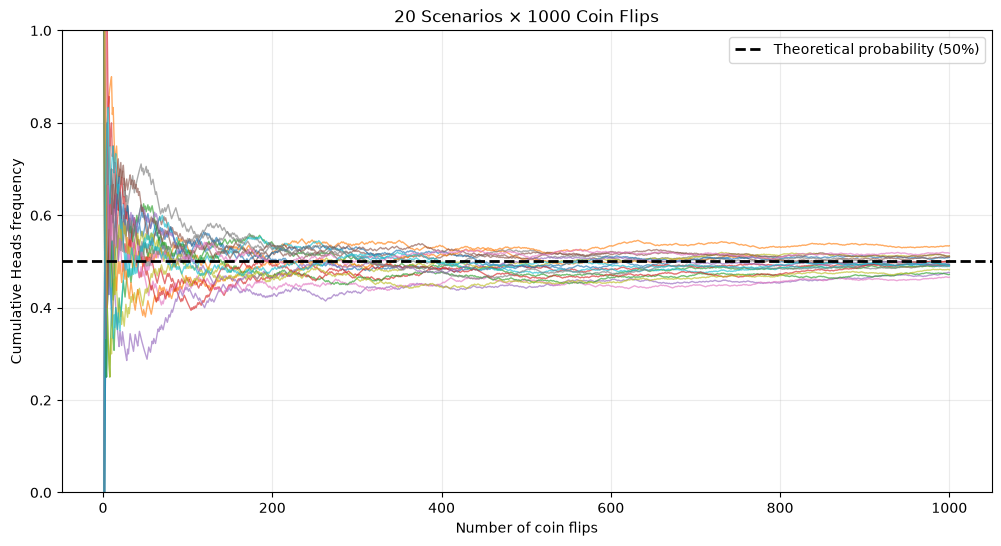

In [147]:
# Visualizing

plt.figure(figsize=(12, 6))

for scenario in range(n_experiments):
    plt.plot(
        flip_numbers,
        cumulative_frequency[scenario],
        alpha=0.65,
        linewidth=1
    )

# Theoretical probability line
plt.axhline(
    y=0.5,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Theoretical probability (50%)"
)

plt.xlabel("Number of coin flips")
plt.ylabel("Cumulative Heads frequency")
plt.title(
    f"{n_experiments} Scenarios × {x_flips} Coin Flips"
)
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

In [150]:
# analyzing the final frequency of each scenario
final_frequencies = cumulative_frequency[:, -1]

# Summarizing results
print("Number of scenarios:", n_experiments)
print("Flips per scenario:", x_flips)
print("Total coin flips:", n_experiments * x_flips)
print(
    "Mean final frequency:",
    f"{final_frequencies.mean():.2%}"
)
print(
    "Minimum final frequency:",
    f"{final_frequencies.min():.2%}"
)
print(
    "Maximum final frequency:",
    f"{final_frequencies.max():.2%}"
)

Number of scenarios: 20
Flips per scenario: 1000
Total coin flips: 20000
Mean final frequency: 49.64%
Minimum final frequency: 46.60%
Maximum final frequency: 53.40%


## Insights

**1. Randomness does not mean that anything is possible**

A fair coin has two possible outcomes, heads and tails, each with a 50% probability. Although the outcome is uncertain, the rules of the experiment are well-defined.

**2. Independence does not imply that the results must change**

Five consecutive Heads are possible. If the flips are independent, the next one still has a 50% probability of being Heads, regardless of the previous results.

**3. Theoretical probability and observed frequency are different**

Theoretical probability describes the model, observed frequency describes what happened in a specific sample. Obtaining a result different from 50% does not automatically contradict the model.

**4. The Law of Large Numbers does not eliminate randomness**

As the number of independent tosses increases, the relative frequency tends to converge toward the theoretical probability. It may fluctuate, temporarily deviate from 50%, and ultimately fail to reach it exactly.

**5. A simulation allows us to explore possible scenarios**

Repeating a computational experiment generates different trajectories. The results may coincide or differ. Simulation helps us study a model, it does not predict the exact sequence that will occur in reality.

# 02 - Two Investors, Two Futures